In [2]:
import pandas as pd

products = pd.read_csv('/home/pateisreal/projects/ML_project/ML-project/data/processed/products.csv')
products.head(10)

,user_id,item_id,rating,title,features,description,image_url
0,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B09S6Y5BRG,5.0,Otium Bluetooth Earbuds Wireless Headphones Bl...,['True HD High Fidelity Sound.Update Bluetooth...,[],https://m.media-amazon.com/images/I/41sN-XYld0...
1,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B01LW71IBJ,5.0,Logitech Z313 Speaker System + Logitech Blueto...,['The control pod makes it easy to control vol...,[],https://m.media-amazon.com/images/I/41S1uuypGR...
2,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B017T99JPG,5.0,Bose SoundLink Mini Bluetooth Speaker II (Carbon),['Big sound with deep bass for a full range li...,"[""It's the small speaker with the big, big voi...",https://m.media-amazon.com/images/I/41SqVGnpzU...
3,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B00L0YLRUW,1.0,NETGEAR Wi-Fi Range Extender EX2700 - Coverage...,['N300 WI-FI speed: Provides up to 300 Mbps pe...,"['Say goodbye to Wi-Fi dead zones. Convenient,...",https://m.media-amazon.com/images/I/31mI-til0g...
4,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B01HHURN3W,3.0,Besdata Magnetic Smart Cover & Translucent Bac...,"['It protects the back as well as the screen, ...",['- 2 SEPARATED PIECES DESIGN: It protects the...,https://m.media-amazon.com/images/I/31sa8fBSGQ...
5,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B0047T79VS,3.0,Belkin F8Z492TTP Bluetooth Music Receiver,['Features Bluetooth v2.0 with EDR for superio...,['Product Description'\n 'Belkin F8Z492TTP Blu...,https://m.media-amazon.com/images/I/316OqhKZ1b...
6,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,B0BNX9QVXZ,5.0,Lepow Portable Monitor - 2023 C2 15.6 inch FHD...,['【1080P FHD IPS High Definition Screen】Lepow ...,[],https://m.media-amazon.com/images/I/51xeaSJD-i...
7,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,B001FWYGJS,4.0,"TP-Link N300 Wireless Extender, Wi-Fi Router (...",['Wireless N speed up to 300 Mbps ideal applic...,['300Mbps Wireless N Router TL-WR841N is a com...,https://m.media-amazon.com/images/I/31qVKOKwoh...
8,AHITBJSS7KYUBVZPX7M2WJCOIVKQ,B07GVWH35S,5.0,HDMI Cable 8K / 4K – 15ft – with A.I.S Shieldi...,['The 8K HDMI cable features a special A.I.S. ...,"['4K HDMI Cable, HDMI Cord (15 feet HDMI to HD...",https://m.media-amazon.com/images/I/41FEV9B7eM...
9,AHITBJSS7KYUBVZPX7M2WJCOIVKQ,B00NWXM5U0,2.0,"Fitbit Charge Wireless Activity Wristband, Bla...",['Charge syncs automatically and wireless to t...,"['Product Description'\n ""Energize your day wi...",https://m.media-amazon.com/images/I/41wN7yziTQ...


In [2]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 2815510 entries, 0 to 2815509
Data columns (total 7 columns):
 #   Column       Dtype  
---  ------       -----  
 0   user_id      str    
 1   item_id      str    
 2   rating       float64
 3   title        str    
 4   features     str    
 5   description  str    
 6   image_url    str    
dtypes: float64(1), str(6)
memory usage: 4.4 GB


In [3]:
#check if there any replicated items
print(products.duplicated(subset=['item_id']).sum())

2813510


In [4]:
# create items tables 
items_df = products[['item_id', 'title', 'description', 'features','image_url']]
# remove duplicates
items_df = items_df.drop_duplicates(subset=['item_id'])

# reset index
items_df = items_df.reset_index(drop=True)

items_df.head(10)

,item_id,title,description,features,image_url
0,B09S6Y5BRG,Otium Bluetooth Earbuds Wireless Headphones Bl...,[],['True HD High Fidelity Sound.Update Bluetooth...,https://m.media-amazon.com/images/I/41sN-XYld0...
1,B01LW71IBJ,Logitech Z313 Speaker System + Logitech Blueto...,[],['The control pod makes it easy to control vol...,https://m.media-amazon.com/images/I/41S1uuypGR...
2,B017T99JPG,Bose SoundLink Mini Bluetooth Speaker II (Carbon),"[""It's the small speaker with the big, big voi...",['Big sound with deep bass for a full range li...,https://m.media-amazon.com/images/I/41SqVGnpzU...
3,B00L0YLRUW,NETGEAR Wi-Fi Range Extender EX2700 - Coverage...,"['Say goodbye to Wi-Fi dead zones. Convenient,...",['N300 WI-FI speed: Provides up to 300 Mbps pe...,https://m.media-amazon.com/images/I/31mI-til0g...
4,B01HHURN3W,Besdata Magnetic Smart Cover & Translucent Bac...,['- 2 SEPARATED PIECES DESIGN: It protects the...,"['It protects the back as well as the screen, ...",https://m.media-amazon.com/images/I/31sa8fBSGQ...
5,B0047T79VS,Belkin F8Z492TTP Bluetooth Music Receiver,['Product Description'\n 'Belkin F8Z492TTP Blu...,['Features Bluetooth v2.0 with EDR for superio...,https://m.media-amazon.com/images/I/316OqhKZ1b...
6,B0BNX9QVXZ,Lepow Portable Monitor - 2023 C2 15.6 inch FHD...,[],['【1080P FHD IPS High Definition Screen】Lepow ...,https://m.media-amazon.com/images/I/51xeaSJD-i...
7,B001FWYGJS,"TP-Link N300 Wireless Extender, Wi-Fi Router (...",['300Mbps Wireless N Router TL-WR841N is a com...,['Wireless N speed up to 300 Mbps ideal applic...,https://m.media-amazon.com/images/I/31qVKOKwoh...
8,B07GVWH35S,HDMI Cable 8K / 4K – 15ft – with A.I.S Shieldi...,"['4K HDMI Cable, HDMI Cord (15 feet HDMI to HD...",['The 8K HDMI cable features a special A.I.S. ...,https://m.media-amazon.com/images/I/41FEV9B7eM...
9,B00NWXM5U0,"Fitbit Charge Wireless Activity Wristband, Bla...","['Product Description'\n ""Energize your day wi...",['Charge syncs automatically and wireless to t...,https://m.media-amazon.com/images/I/41wN7yziTQ...


In [5]:
# check if duplicated items are removed
print(items_df.duplicated(subset=['item_id']).sum())
print(items_df.info())

0
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   item_id      2000 non-null   str  
 1   title        2000 non-null   str  
 2   description  2000 non-null   str  
 3   features     2000 non-null   str  
 4   image_url    2000 non-null   str  
dtypes: str(5)
memory usage: 3.2 MB
None


In [6]:
# save items_df to csv
items_df.to_csv('/home/pateisreal/projects/ML_project/ML-project/data/processed/items.csv', index=False)

In [7]:
#create ratings tables
rating_df = products[['user_id', 'item_id', 'rating']]

rating_df = rating_df.drop_duplicates(subset=['user_id', 'item_id'])
rating_df.head(10)

,user_id,item_id,rating
0,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B09S6Y5BRG,5.0
1,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B01LW71IBJ,5.0
2,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B017T99JPG,5.0
3,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B00L0YLRUW,1.0
4,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B01HHURN3W,3.0
5,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B0047T79VS,3.0
6,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,B0BNX9QVXZ,5.0
7,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,B001FWYGJS,4.0
8,AHITBJSS7KYUBVZPX7M2WJCOIVKQ,B07GVWH35S,5.0
9,AHITBJSS7KYUBVZPX7M2WJCOIVKQ,B00NWXM5U0,2.0


In [9]:
# check if the user_id and item_id pairs are unique
print(rating_df.duplicated(subset=['user_id', 'item_id']).sum())
print(rating_df.info())

# save rating_df to csv
rating_df.to_csv('/home/pateisreal/projects/ML_project/ML-project/data/processed/ratings.csv', index=False)

0
<class 'pandas.DataFrame'>
Index: 2758755 entries, 0 to 2815509
Data columns (total 3 columns):
 #   Column   Dtype  
---  ------   -----  
 0   user_id  str    
 1   item_id  str    
 2   rating   float64
dtypes: float64(1), str(2)
memory usage: 184.8 MB
None


In [10]:
# before we go to contextual embedding
# we need to check text lenght of title , feature and description are longer enough for the model to learn from it

# lenght in characters
items_df["lenght_title"] = items_df["title"].fillna("").str.len()
items_df["lenght_description"] = items_df["description"].fillna("").str.len()
items_df["lenght_feature"] = items_df["features"].fillna("").str.len()

print(items_df[["lenght_title", "lenght_description", "lenght_feature"]].describe())

       lenght_title  lenght_description  lenght_feature
count    2000.00000          2000.00000     2000.000000
mean      122.89700           648.18050      789.391500
std        51.50931          1305.07452      467.930865
min        12.00000             2.00000        2.000000
25%        80.00000             2.00000      430.000000
50%       117.00000           160.00000      718.500000
75%       174.00000           755.75000     1084.500000
max       249.00000         28062.00000     3224.000000


In [11]:
# check tokens
items_df["tok_title"] = items_df["title"].fillna("").str.split().apply(len)
items_df["tok_desc"] = items_df["description"].fillna("").str.split().apply(len)
items_df["tok_feat"] = items_df["features"].fillna("").str.split().apply(len)

print(items_df[["tok_title","tok_desc","tok_feat"]].describe())

         tok_title    tok_desc     tok_feat
count  2000.000000  2000.00000  2000.000000
mean     19.543500   101.03500   122.588000
std       8.680656   206.46347    75.501341
min       2.000000     1.00000     1.000000
25%      12.000000     1.00000    64.000000
50%      19.000000    24.00000   108.500000
75%      27.000000   117.00000   171.000000
max      47.000000  4872.00000   565.000000


In [12]:
# check some examples
items_df.sample(5)[["title","description","features"]]

,title,description,features
1433,LG GP65NB60 8X USB 2.0 Super Multi Ultra Slim ...,['LG GP65NB60 8X USB 2.0 Ultra Slim Portable D...,['14 millimeter height ultra slim portable DVD...
1085,SABRENT USB 3.2 Rugged Waterproof Enclosure [I...,[],['WATER RESISTANCE - Fully compliant with IP67...
31,"JBL Flip 4, Black - Waterproof, Portable & Dur...",['Product Description'\n 'JBL Flip 4 is the ne...,['All-Purpose Bluetooth Speaker -Take the part...
1335,HD eRapta ERT02 Backup Camera Rear View Licens...,[],"['Excellent license plate wired backup camera,..."
181,"Anker USB Travel Power Strip, 321 Power Strip ...",[],['One for All: 3 AC outlets and 3 USB ports po...


In [13]:
# check how many items have empty description 
print((items_df["description"].fillna("[]") == "[]").sum())

820


In [14]:
# let remove the symbol [] from description and features
import ast

def clean_list_text(x):
    if pd.isna(x):
        return ""

    if isinstance(x, list):
        return " ".join(map(str, x))

    if isinstance(x, str):
        x = x.strip()

        # Only try parsing if it looks like a list
        if x.startswith("[") and x.endswith("]"):
            try:
                val = ast.literal_eval(x)
                if isinstance(val, list):
                    return " ".join(map(str, val))
            except:
                return x

        return x        

    return ""

items_df["description"] = items_df["description"].apply(clean_list_text)
items_df["features"] = items_df["features"].apply(clean_list_text)  
items_df["title"] = items_df["title"].apply(clean_list_text)


In [15]:
items_df[["title", "description", "features"]].sample(5)

,title,description,features
1748,Rankie Mini DisplayPort (Mini DP) to HDMI Cabl...,,The 6 feet cable connects a Mini DisplayPort w...
1111,Wacom Intuos Pen and Touch Medium Tablet (CTH6...,<br><h3>Model</h3><strong>Brand: </strong>Waco...,Have fun with digital art and photos with incl...
1200,"[Apple MFi Certified] iPhone Charger, YUNSONG ...",Features:Brand: YUNSONG Cover Material: Nylon ...,DURABLE DESIGN: Covered with braided-nylon jac...
954,Roku 3 Streaming Media Player (4230R) with Voi...,"Roku 3 is the fastest, most powerful Roku play...",Compact stick design. Plugs discreetly right i...
1470,BlueParrott B450-XT Noise Cancelling Bluetooth...,Engineered for superior calls in high-noise en...,Industry leading sound: The BlueParrott B450 X...


In [17]:
# there are a lot of items with empty description, we will merge title and features and description 
# we will avoid repeating whole duplicated fields.

import ast
import pandas as pd
from difflib import SequenceMatcher

def clean_features(x):
    if pd.isna(x):
        return ""

    if isinstance(x, list):
        return " ".join(map(str, x))

    if isinstance(x, str):
        x = x.strip()

        # only parse stringified lists like "['a', 'b']"
        if x.startswith("[") and x.endswith("]"):
            try:
                lst = ast.literal_eval(x)
                if isinstance(lst, list):
                    return " ".join(map(str, lst))
            except Exception:
                return x

        return x

    return ""

def is_similar(a, b, threshold=0.85):
    a = str(a).lower().strip()
    b = str(b).lower().strip()

    if len(a) == 0 or len(b) == 0:
        return False

    return SequenceMatcher(None, a, b).ratio() >= threshold

def build_text(row):
    title = str(row["title"]) if pd.notna(row["title"]) else ""
    desc = str(row["description"]) if pd.notna(row["description"]) else ""
    feat = clean_features(row["features"])

    parts = []

    if title:
        parts.append(title)

    if desc and not is_similar(desc, title):
        parts.append(desc)

    if feat and not is_similar(feat, title) and not is_similar(feat, desc):
        parts.append(feat)

    return ". ".join(parts).replace("\n", " ").strip()

items_df["text"] = items_df.apply(build_text, axis=1)
items_df["tok_len"] = items_df["text"].str.split().apply(len)

items_df[["title", "description", "features", "text", "tok_len"]].sample(5)

,title,description,features,text,tok_len
1780,HP VH240a 23.8-Inch Full HD 1080p IPS LED Moni...,Get the best productivity from home or at the ...,This Certified Refurbished product is manufact...,HP VH240a 23.8-Inch Full HD 1080p IPS LED Moni...,240
1706,JETech Case for iPad 10.2-Inch (2021/2020/2019...,"JETech Case for iPad 9/8 / 7 (10.2-Inch, 2021/...",Designed for 10.2 inch iPad (2021 2020 2019 mo...,JETech Case for iPad 10.2-Inch (2021/2020/2019...,104
1886,"VideoSecu Tilt Swivel TV Wall Mount 32""- 70"" L...",The VideoSecu dual arm articulating wall mount...,Fits most 32-70 inch TV with mounting hole pat...,"VideoSecu Tilt Swivel TV Wall Mount 32""- 70"" L...",346
1651,SAMSUNG T5 Portable SSD 2TB - Up to 540MB/s - ...,The Samsung T5 Portable SSD has the latest in ...,Superfast read-write speeds of up to 540 MB/sT...,SAMSUNG T5 Portable SSD 2TB - Up to 540MB/s - ...,99
1597,Monoprice 103033 RG6 Quad Shield CL2 Coaxial C...,It is a heavy-Duty Quad Shielded RG-6/UL 18AWG...,It is a 75 Ohm 2200 MHz Coaxial Cables for Max...,Monoprice 103033 RG6 Quad Shield CL2 Coaxial C...,80


In [18]:
# drop items with token length less than 5
items_df = items_df[items_df["tok_len"] >= 5].reset_index(drop=True)

In [19]:
items_df.to_csv('/home/pateisreal/projects/ML_project/ML-project/data/processed/items_text.csv', index=False)

In [35]:
items_text = pd.read_csv('/home/pateisreal/projects/ML_project/ML-project/data/processed/items_text.csv')
items_text.head(10)

,item_id,title,description,features,image_url,lenght_title,lenght_description,lenght_feature,tok_title,tok_desc,tok_feat,text,tok_len
0,B09S6Y5BRG,Otium Bluetooth Earbuds Wireless Headphones Bl...,NaN,True HD High Fidelity Sound.Update Bluetooth H...,https://m.media-amazon.com/images/I/41sN-XYld0...,173,2,1197,22,1,178,Otium Bluetooth Earbuds Wireless Headphones Bl...,196
1,B01LW71IBJ,Logitech Z313 Speaker System + Logitech Blueto...,NaN,The control pod makes it easy to control volum...,https://m.media-amazon.com/images/I/41S1uuypGR...,70,2,589,10,1,91,Logitech Z313 Speaker System + Logitech Blueto...,96
2,B017T99JPG,Bose SoundLink Mini Bluetooth Speaker II (Carbon),"It's the small speaker with the big, big voice...",Big sound with deep bass for a full range list...,https://m.media-amazon.com/images/I/41SqVGnpzU...,49,1144,494,7,192,78,Bose SoundLink Mini Bluetooth Speaker II (Carb...,273
3,B00L0YLRUW,NETGEAR Wi-Fi Range Extender EX2700 - Coverage...,"Say goodbye to Wi-Fi dead zones. Convenient, d...",N300 WI-FI speed: Provides up to 300 Mbps perf...,https://m.media-amazon.com/images/I/31mI-til0g...,174,582,739,31,93,108,NETGEAR Wi-Fi Range Extender EX2700 - Coverage...,228
4,B01HHURN3W,Besdata Magnetic Smart Cover & Translucent Bac...,- 2 SEPARATED PIECES DESIGN: It protects the b...,"It protects the back as well as the screen, wh...",https://m.media-amazon.com/images/I/31sa8fBSGQ...,134,673,453,24,116,77,Besdata Magnetic Smart Cover & Translucent Bac...,213
5,B0047T79VS,Belkin F8Z492TTP Bluetooth Music Receiver,Product DescriptionBelkin F8Z492TTP Bluetooth ...,Features Bluetooth v2.0 with EDR for superior ...,https://m.media-amazon.com/images/I/316OqhKZ1b...,41,3945,251,5,576,34,Belkin F8Z492TTP Bluetooth Music Receiver. Pro...,564
6,B0BNX9QVXZ,Lepow Portable Monitor - 2023 C2 15.6 inch FHD...,NaN,【1080P FHD IPS High Definition Screen】Lepow C2...,https://m.media-amazon.com/images/I/51xeaSJD-i...,193,2,1240,33,1,178,Lepow Portable Monitor - 2023 C2 15.6 inch FHD...,207
7,B001FWYGJS,"TP-Link N300 Wireless Extender, Wi-Fi Router (...",300Mbps Wireless N Router TL-WR841N is a combi...,Wireless N speed up to 300 Mbps ideal applicat...,https://m.media-amazon.com/images/I/31qVKOKwoh...,131,432,904,21,58,138,"TP-Link N300 Wireless Extender, Wi-Fi Router (...",211
8,B07GVWH35S,HDMI Cable 8K / 4K – 15ft – with A.I.S Shieldi...,"4K HDMI Cable, HDMI Cord (15 feet HDMI to HDMI...",The 8K HDMI cable features a special A.I.S. (a...,https://m.media-amazon.com/images/I/41FEV9B7eM...,199,178,991,35,30,134,HDMI Cable 8K / 4K – 15ft – with A.I.S Shieldi...,195
9,B00NWXM5U0,"Fitbit Charge Wireless Activity Wristband, Bla...",Product DescriptionEnergize your day with the ...,Charge syncs automatically and wireless to tab...,https://m.media-amazon.com/images/I/41wN7yziTQ...,55,2017,970,7,332,159,"Fitbit Charge Wireless Activity Wristband, Bla...",486


contextual embeddings :
input : products.csv, item_id, title, description, iage_url, rating from user
out put: vectors/vec_bert.pkl
        vectors/vec_image.pkl
        vectors/vec_vert_image.pkl

In [21]:
# BERT text embedding from title + description + features

import numpy as np
import torch
import joblib
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel

item_ids = items_text["item_id"].values
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert = AutoModel.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
bert = bert.to(device)
bert.eval()

def get_bert_embedding(texts,batch_size = 64, max_length = 128):
    embeddings = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i : i + batch_size]

        encoded = tokenizer(
            list(batch_texts),
            padding=True,
            truncation=True,
            max_length=max_length, 
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = bert(**encoded)
        
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        embeddings.append(cls_embeddings.cpu().numpy())

    return np.vstack(embeddings)

X_bert = get_bert_embedding(items_text["text"].values)

print(X_bert.shape)
joblib.dump((X_bert, item_ids), "/home/pateisreal/projects/ML_project/ML-project/vectors/vec_bert.pkl")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: cuda


100%|██████████| 32/32 [00:09<00:00,  3.44it/s]

(2000, 768)


['/home/pateisreal/projects/ML_project/ML-project/vectors/vec_bert.pkl']

In [34]:
# check vectors 
import joblib
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

X_bert, item_ids = joblib.load(
    "/home/pateisreal/projects/ML_project/ML-project/vectors/vec_bert.pkl"
)

print("Shape:", X_bert.shape)          # should be (2000, 768)
print("Mean:", np.mean(X_bert))
print("Std:", np.std(X_bert))
print("NaN values:", np.isnan(X_bert).sum())

zero_rows = np.sum(np.all(X_bert == 0, axis=1))
print("Zero vectors:", zero_rows)

norms = np.linalg.norm(X_bert, axis=1)
print("Min norm:", norms.min())
print("Max norm:", norms.max())
print("Mean norm:", norms.mean())

Shape: (2000, 768)
Mean: -0.011321336
Std: 0.5557934
NaN values: 0
Zero vectors: 0
Min norm: 13.256278
Max norm: 17.005495
Mean norm: 15.398413


In [32]:
# check if similar text items are close
# Normalize for cosine similarity
X_bert_norm = X_bert / (np.linalg.norm(X_bert, axis=1, keepdims=True) + 1e-8)

def show_similar_bert(idx, top_k=5):
    query_vec = X_bert_norm[idx]
    sim = X_bert_norm @ query_vec

    nearest = np.argsort(sim)[::-1][1:top_k+1]

    print("\nQuery:")
    print(items_text.iloc[idx]["title"])
    print(items_text.iloc[idx]["text"][:300])

    print("\nTop similar items:")
    for i in nearest:
        print(f"- {items_text.iloc[i]['title']} (score={sim[i]:.3f})")

In [36]:
show_similar_bert(10, top_k=5)


Query:
WD 2TB My Cloud Personal Network Attached Storage - NAS - WDBCTL0020HWT-NESN,White
WD 2TB My Cloud Personal Network Attached Storage - NAS - WDBCTL0020HWT-NESN,White. With My Cloud, WD's personal cloud storage, you can save everything in one place and access it from anywhere with blazing-fast performance. Get abundant storage without paying monthly fees. And with direct file uploa

Top similar items:
- WD 2TB Black My Passport Ultra Portable External Hard Drive - USB 3.0 - WDBBKD0020BBK-NESN (score=0.911)
- Western Digital 4TB Blue My Passport Portable External Hard Drive - USB 3.0 - Western DigitalBYFT0040BBL-WESN (score=0.911)
- Logitech F310 Wired Gamepad Controller Console Like Layout 4 Switch D-Pad PC - Blue/Black (score=0.901)
- SanDisk 32GB Cruzer USB 2.0 Flash Drive, Frustration-Free Packaging- SDCZ36-032G-AFFP (score=0.898)
- (Old Model) WD My Passport Ultra 500 GB Portable External USB 3.0 Hard Drive with Auto Backup, Red (score=0.898)


In [24]:
import random

for _ in range(5):
    idx = random.randint(0, len(items_text)-1)
    show_similar_bert(idx, top_k=5)
    print("="*80)


Query:
1byone Amplified HD Digital TV Antenna - Support 4K 1080p and All Older TV's - Indoor Smart Switch Amplifier Signal Booster - Coax HDTV Cable/AC Adapter
1byone Amplified HD Digital TV Antenna - Support 4K 1080p and All Older TV's - Indoor Smart Switch Amplifier Signal Booster - Coax HDTV Cable/AC Adapter. ✅[Lightweight and Simple Design]- Light and flat design, beautiful enough and easy to install, you can hide it behind the TV set or stick it on th

Top similar items:
- BlueRigger Digital Optical Audio Toslink Cable (3FT, Fiber Optic Cord, 24K Gold-Plated) - Compatible with Home Theatre, Sound Bar, TV, Xbox, Playstation PS5/PS4 (score=0.897)
- Winegard LNA-200 Boost XT HDTV Preamplifier, TV Antenna Amplifier Signal Booster, HD Digital VHF UHF Amplifier,Black (score=0.895)
- GOSKY Smartphone Adapter Mount Regular Size - Compatible with Binoculars, Monoculars, Spotting Scopes, Telescope, Microscopes - Fits almost all Smartphones on the Market - Record Nature and The World (score

In [ ]:
# ==========================================
# Step 1: Download images 
# ==========================================

import os
import requests
import numpy as np
import pandas as pd
import torch
import joblib
from tqdm import tqdm
from PIL import Image
from io import BytesIO
from torchvision import models, transforms

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

image_dir = "/home/pateisreal/projects/ML_project/ML-project/data/images_64"
os.makedirs(image_dir, exist_ok=True)

urls = items_text["image_url"].fillna("").values
item_ids = items_text["item_id"].values   # change if your id column is different

def download_and_resize_image(url, save_path, size=(224, 224)):
    try:
        if os.path.exists(save_path):
            return True

        response = requests.get(url, timeout=5)
        response.raise_for_status()

        img = Image.open(BytesIO(response.content)).convert("RGB")
        img = img.resize(size)

        img.save(save_path)
        return True

    except Exception:
        return False


image_paths = []

for item_id, url in tqdm(zip(item_ids, urls), total=len(urls)):
    save_path = os.path.join(image_dir, f"{item_id}.jpg")

    ok = download_and_resize_image(url, save_path)

    if ok:
        image_paths.append(save_path)
    else:
        image_paths.append(None)

items_text["local_image_path"] = image_paths

items_text.to_csv(
    "/home/pateisreal/projects/ML_project/ML-project/data/processed/items_with_images.csv",
    index=False
)

print("Downloaded/resized images:", sum(p is not None for p in image_paths))

Device: cuda


100%|██████████| 2000/2000 [01:31<00:00, 21.93it/s]


Downloaded/resized images: 2000


In [3]:
items = pd.read_csv("/home/pateisreal/projects/ML_project/ML-project/data/processed/items_with_images.csv")
items.head(5)

,item_id,title,description,features,image_url,lenght_title,lenght_description,lenght_feature,tok_title,tok_desc,tok_feat,text,tok_len,local_image_path
0,B09S6Y5BRG,Otium Bluetooth Earbuds Wireless Headphones Bl...,NaN,True HD High Fidelity Sound.Update Bluetooth H...,https://m.media-amazon.com/images/I/41sN-XYld0...,173,2,1197,22,1,178,Otium Bluetooth Earbuds Wireless Headphones Bl...,196,/home/pateisreal/projects/ML_project/ML-projec...
1,B01LW71IBJ,Logitech Z313 Speaker System + Logitech Blueto...,NaN,The control pod makes it easy to control volum...,https://m.media-amazon.com/images/I/41S1uuypGR...,70,2,589,10,1,91,Logitech Z313 Speaker System + Logitech Blueto...,96,/home/pateisreal/projects/ML_project/ML-projec...
2,B017T99JPG,Bose SoundLink Mini Bluetooth Speaker II (Carbon),"It's the small speaker with the big, big voice...",Big sound with deep bass for a full range list...,https://m.media-amazon.com/images/I/41SqVGnpzU...,49,1144,494,7,192,78,Bose SoundLink Mini Bluetooth Speaker II (Carb...,273,/home/pateisreal/projects/ML_project/ML-projec...
3,B00L0YLRUW,NETGEAR Wi-Fi Range Extender EX2700 - Coverage...,"Say goodbye to Wi-Fi dead zones. Convenient, d...",N300 WI-FI speed: Provides up to 300 Mbps perf...,https://m.media-amazon.com/images/I/31mI-til0g...,174,582,739,31,93,108,NETGEAR Wi-Fi Range Extender EX2700 - Coverage...,228,/home/pateisreal/projects/ML_project/ML-projec...
4,B01HHURN3W,Besdata Magnetic Smart Cover & Translucent Bac...,- 2 SEPARATED PIECES DESIGN: It protects the b...,"It protects the back as well as the screen, wh...",https://m.media-amazon.com/images/I/31sa8fBSGQ...,134,673,453,24,116,77,Besdata Magnetic Smart Cover & Translucent Bac...,213,/home/pateisreal/projects/ML_project/ML-projec...


In [4]:
# create image embedding using resnet18 pretrained on imagenet
import os
import numpy as np
import torch
import joblib
from PIL import Image
from tqdm import tqdm
from torchvision import models, transforms

device = "cuda" if torch.cuda.is_available() else "cpu"

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = torch.nn.Identity()

for p in resnet.parameters():
    p.requires_grad = False

resnet = resnet.to(device)
resnet.eval()

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def load_local_image(path):
    try:
        if path is None or not os.path.exists(path):
            return None
        img = Image.open(path).convert("RGB")
        return image_transform(img)
    except:
        return None

paths = items["local_image_path"].values
item_ids = items["item_id"].values

batch_size = 16
image_embeddings = []

for i in tqdm(range(0, len(paths), batch_size)):
    batch_paths = paths[i:i + batch_size]

    batch_imgs = []
    valid_pos = []

    for j, path in enumerate(batch_paths):
        img = load_local_image(path)
        if img is not None:
            batch_imgs.append(img)
            valid_pos.append(j)

    batch_output = np.zeros((len(batch_paths), 512))

    if len(batch_imgs) > 0:
        batch_tensor = torch.stack(batch_imgs).to(device)

        with torch.no_grad():
            emb = resnet(batch_tensor).cpu().numpy()

        for k, pos in enumerate(valid_pos):
            batch_output[pos] = emb[k]

    image_embeddings.append(batch_output)

X_image = np.vstack(image_embeddings)

print(X_image.shape)

joblib.dump(
    (X_image, item_ids),
    "/home/pateisreal/projects/ML_project/ML-project/vectors/vec_image.pkl"
)


100%|██████████| 125/125 [00:03<00:00, 39.85it/s]

(2000, 512)


['/home/pateisreal/projects/ML_project/ML-project/vectors/vec_image.pkl']

In [5]:
print("Shape:", X_image.shape)

print("Mean:", np.mean(X_image))
print("Std:", np.std(X_image))

# check zero vectors
zero_rows = np.sum(np.all(X_image == 0, axis=1))
print("Zero vectors:", zero_rows)

Shape: (2000, 512)
Mean: 0.8553437755162118
Std: 0.8902382448907031
Zero vectors: 0


we check image embedding, by ploting nearest neighbors using cosine similariy. check if similar items were found to be close in the embendding space. 

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(X_image)

def show_similar(idx, top_k=5):
    sim = similarity[idx]
    nearest = np.argsort(sim)[::-1][1:top_k+1]

    print("Query:", items.iloc[idx]["title"])

    for i in nearest:
        print(" -", items.iloc[i]["title"])

In [8]:
for _ in range(5):
    idx = np.random.randint(0, len(items))
    show_similar(idx, top_k=5)


Query: Echo (4th Gen) | Glacier White with Sengled Bluetooth Color bulb | Alexa smart home starter kit
 - Philips SmartSleep Wake-up Light, Colored Sunrise and Sunset Simulation, 5 Natural Sounds, FM Radio & Reading Lamp, Tap Snooze, HF3520/60
 - Google Chromecast - Streaming Device with HDMI Cable - Stream Shows, Music, Photos, and Sports from Your Phone to Your TV
 - Logitech MX Ergo Wireless Trackball Mouse Adjustable Ergonomic Design, Control and Move Text/Images/Files Between 2 Windows and Apple Mac Computers (Bluetooth or USB), Rechargeable, Graphite - Black
 - TP-Link Deco Mesh WiFi System(Deco M5) –Up to 5,500 sq. ft. Whole Home Coverage and 100+ Devices,WiFi Router/Extender Replacement, Anitivirus, 3-pack
 - Logitech M570 Wireless Trackball Mouse – Ergonomic Design with Sculpted Right-Hand Shape, Compatible with Apple Mac / Microsoft, USB Unifying Receiver, Dark Gray (Discontinued by Manufacturer)
Query: Bayco KW-110 Cord Reel, Orange
 - Fotodiox Lens Mount Adapter Compatible 

In [14]:
show_similar(10, top_k=5)

Query: WD 2TB My Cloud Personal Network Attached Storage - NAS - WDBCTL0020HWT-NESN,White
 - WD 18TB Elements Desktop External Hard Drive, USB 3.0 external hard drive for plug-and-play storage - WDBWLG0180HBK-NESN
 - WD 4TB My Book Desktop External Hard Drive - USB 3.0 - WDBFJK0040HBK-NESN,Black
 - NETGEAR Orbi Whole Home Tri-band Mesh WiFi 6 System (RBK752) – Router with 1 Satellite Extender | Coverage up to 5,000 sq. ft., 40 Devices | AX4200 (Up to 4.2Gbps)
 - Anker Soundcore Liberty Air 2 Wireless Earbuds, Diamond-Inspired Drivers, Bluetooth Earphones, 4 Mics, Noise Reduction, 28H Playtime, HearID, Bluetooth 5, Wireless Charging, for Calls, Home Office
 - Belkin 7-Outlet Commercial Power Strip Surge Protector with 6ft Power Cord, 750 Joules , White


image embeddings work partially but they are not reliable alone

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA to 2D
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_image)

# normalize for cosine similarity
norms = np.linalg.norm(X_image, axis=1, keepdims=True)
X_norm = X_image / (norms + 1e-8)

def plot_neighbors(idx, top_k=5):
    query_vec = X_norm[idx]
    sim = X_norm @ query_vec

    nearest = np.argsort(sim)[::-1][1:top_k+1]

    plt.figure(figsize=(8,6))

    # plot all points (light)
    plt.scatter(X_2d[:,0], X_2d[:,1], alpha=0.2, color="gray")

    # plot query point
    plt.scatter(
        X_2d[idx,0], X_2d[idx,1],
        color="red", s=120, label="Query"
    )

    # plot neighbors
    for i in nearest:
        plt.scatter(
            X_2d[i,0], X_2d[i,1],
            color="blue", s=80
        )

        # show short title
        title = items.iloc[i]["title"][:30]
        plt.text(X_2d[i,0], X_2d[i,1], title, fontsize=8)

    # label query
    plt.text(
        X_2d[idx,0], X_2d[idx,1],
        "QUERY",
        fontsize=10,
        color="red"
    )

    plt.title("PCA Image Embedding + Nearest Neighbors")
    plt.legend()
    plt.show()

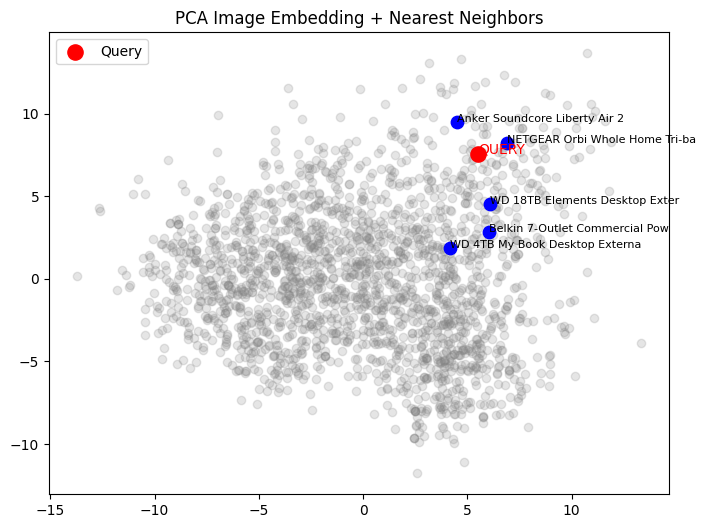

In [12]:
plot_neighbors(10, top_k=5)

image only with K = 2, could be better.
BERT only with k 5 or 10
let check if BERT + image

In [16]:
# combine BERT and  image embeddings 
import joblib
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_bert, item_ids_bert = joblib.load("/home/pateisreal/projects/ML_project/ML-project/vectors/vec_bert.pkl")
X_image, item_ids_image = joblib.load("/home/pateisreal/projects/ML_project/ML-project/vectors/vec_image.pkl")

assert list(item_ids_bert) == list(item_ids_image)

bert_scaled = StandardScaler().fit_transform(X_bert)
image_scaled = StandardScaler().fit_transform(X_image)

pca = PCA(n_components=128, random_state=42)
image_reduced = pca.fit_transform(image_scaled)

X_bert_image = np.hstack([bert_scaled, image_reduced])

print(X_bert_image.shape)

joblib.dump(
    (X_bert_image, item_ids_bert),
    "/home/pateisreal/projects/ML_project/ML-project/vectors/vec_bert_image.pkl"
)

(2000, 896)


['/home/pateisreal/projects/ML_project/ML-project/vectors/vec_bert_image.pkl']

In [18]:
X_norm = X_bert_image / (np.linalg.norm(X_bert_image, axis=1, keepdims=True) + 1e-8)

def show_similar_combined(idx, top_k=5):
    sim = X_norm @ X_norm[idx]
    nearest = np.argsort(sim)[::-1][1:top_k+1]

    print("Query:", items.iloc[idx]["title"])
    print("\nTop similar:")
    for i in nearest:
        print(f"- {items.iloc[i]['title']} (score={sim[i]:.3f})")

show_similar_combined(10, top_k=5)

Query: WD 2TB My Cloud Personal Network Attached Storage - NAS - WDBCTL0020HWT-NESN,White

Top similar:
- NETGEAR Orbi Whole Home Tri-band Mesh WiFi 6 System (RBK752) – Router with 1 Satellite Extender | Coverage up to 5,000 sq. ft., 40 Devices | AX4200 (Up to 4.2Gbps) (score=0.508)
- WD 4TB My Book Desktop External Hard Drive - USB 3.0 - WDBFJK0040HBK-NESN,Black (score=0.456)
- WD My Book 1.5TB External Hard Drive Storage USB 3.0 File Backup and Storage (score=0.443)
- WD 2TB Black My Passport Ultra Portable External Hard Drive - USB 3.0 - WDBBKD0020BBK-NESN (score=0.422)
- TP-Link Deco Whole Home Mesh WiFi System (Deco S4) – Up to 2,000 Sq.ft. Coverage, WiFi Router/Extender Replacement, Gigabit Ports, 1-Pack (score=0.418)


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Use combined vector
X = X_bert_image

# Normalize for cosine similarity
X_norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)

# PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_norm)

def plot_combined_neighbors(idx, top_k=5):
    sim = X_norm @ X_norm[idx]
    nearest = np.argsort(sim)[::-1][1:top_k+1]

    plt.figure(figsize=(10, 7))

    # all points
    plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.15, s=20)

    # query
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], s=160, label="Query")

    # neighbors
    plt.scatter(
        X_2d[nearest, 0],
        X_2d[nearest, 1],
        s=100,
        label="Top similar"
    )

    # labels
    plt.text(
        X_2d[idx, 0],
        X_2d[idx, 1],
        "QUERY",
        fontsize=10,
        weight="bold"
    )

    for rank, i in enumerate(nearest, start=1):
        short_title = items.iloc[i]["title"][:35]
        plt.text(
            X_2d[i, 0],
            X_2d[i, 1],
            f"{rank}. {short_title}",
            fontsize=8
        )

    plt.title("BERT + Image Embeddings: Query and Top Similar Products")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.show()

    print("Query:", items.iloc[idx]["title"])
    print("\nTop similar:")
    for rank, i in enumerate(nearest, start=1):
        print(f"{rank}. {items.iloc[i]['title']} (score={sim[i]:.3f})")

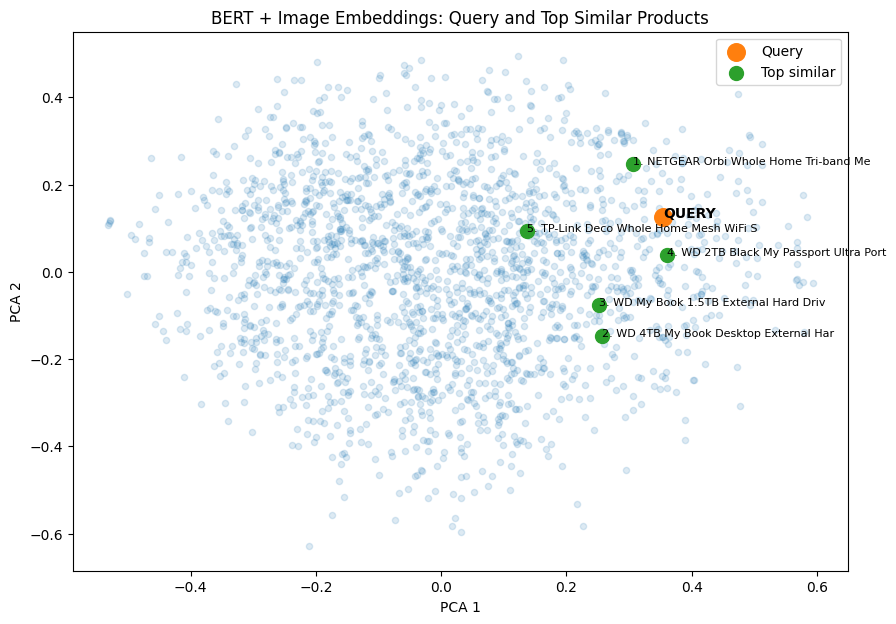

Query: WD 2TB My Cloud Personal Network Attached Storage - NAS - WDBCTL0020HWT-NESN,White

Top similar:
1. NETGEAR Orbi Whole Home Tri-band Mesh WiFi 6 System (RBK752) – Router with 1 Satellite Extender | Coverage up to 5,000 sq. ft., 40 Devices | AX4200 (Up to 4.2Gbps) (score=0.508)
2. WD 4TB My Book Desktop External Hard Drive - USB 3.0 - WDBFJK0040HBK-NESN,Black (score=0.456)
3. WD My Book 1.5TB External Hard Drive Storage USB 3.0 File Backup and Storage (score=0.443)
4. WD 2TB Black My Passport Ultra Portable External Hard Drive - USB 3.0 - WDBBKD0020BBK-NESN (score=0.422)
5. TP-Link Deco Whole Home Mesh WiFi System (Deco S4) – Up to 2,000 Sq.ft. Coverage, WiFi Router/Extender Replacement, Gigabit Ports, 1-Pack (score=0.418)


In [22]:
plot_combined_neighbors(idx=10, top_k=5)

In [24]:
# plot BERT
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Use BERT vectors
X = X_bert

# Normalize
X_norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)

# PCA projection
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_norm)

def plot_bert_neighbors(idx, top_k=5):
    sim = X_norm @ X_norm[idx]
    nearest = np.argsort(sim)[::-1][1:top_k+1]

    plt.figure(figsize=(10,7))

    # all points
    plt.scatter(X_2d[:,0], X_2d[:,1], alpha=0.15, s=20)

    # query point
    plt.scatter(
        X_2d[idx,0], X_2d[idx,1],
        s=160, label="Query"
    )

    # neighbors
    plt.scatter(
        X_2d[nearest,0], X_2d[nearest,1],
        s=100, label="Top similar"
    )

    # label query
    plt.text(
        X_2d[idx,0], X_2d[idx,1],
        "QUERY",
        fontsize=10, weight="bold"
    )

    # label neighbors
    for rank, i in enumerate(nearest, start=1):
        title = items.iloc[i]["title"][:35]
        plt.text(
            X_2d[i,0], X_2d[i,1],
            f"{rank}. {title}",
            fontsize=8
        )

    plt.title("BERT Embeddings: Query + Neighbors")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.show()

    print("Query:", items.iloc[idx]["title"])
    print("\nTop similar:")
    for rank, i in enumerate(nearest, start=1):
        print(f"{rank}. {items.iloc[i]['title']} (score={sim[i]:.3f})")

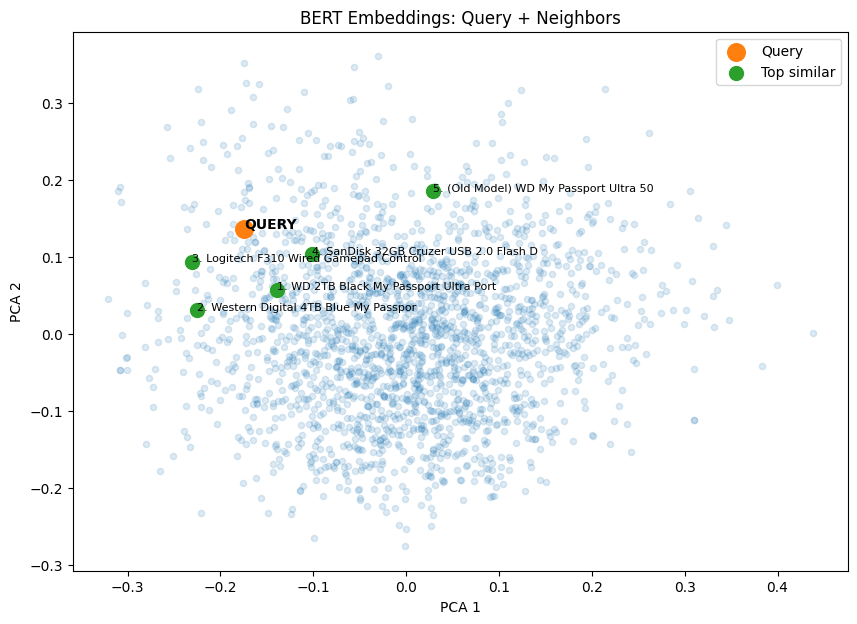

Query: WD 2TB My Cloud Personal Network Attached Storage - NAS - WDBCTL0020HWT-NESN,White

Top similar:
1. WD 2TB Black My Passport Ultra Portable External Hard Drive - USB 3.0 - WDBBKD0020BBK-NESN (score=0.911)
2. Western Digital 4TB Blue My Passport Portable External Hard Drive - USB 3.0 - Western DigitalBYFT0040BBL-WESN (score=0.911)
3. Logitech F310 Wired Gamepad Controller Console Like Layout 4 Switch D-Pad PC - Blue/Black (score=0.901)
4. SanDisk 32GB Cruzer USB 2.0 Flash Drive, Frustration-Free Packaging- SDCZ36-032G-AFFP (score=0.898)
5. (Old Model) WD My Passport Ultra 500 GB Portable External USB 3.0 Hard Drive with Auto Backup, Red (score=0.898)


In [25]:
plot_bert_neighbors(10, top_k=5)

In [27]:
print(len(items))
print(X_bert.shape)
print(X_image.shape)
print(X_bert_image.shape)

print(items.iloc[10]["item_id"])
print(item_ids_bert[10])
print(item_ids_image[10])

2000
(2000, 768)
(2000, 512)
(2000, 896)
B01DDIAX1Q
B01DDIAX1Q
B01DDIAX1Q


In [29]:
assert list(items["item_id"].values) == list(item_ids_bert)
assert list(items["item_id"].values) == list(item_ids_image)

print("All item_ids are aligned correctly.")

All item_ids are aligned correctly.


In [38]:
idx = 20

show_similar_bert(idx, top_k=5)
show_similar(idx, top_k=5)
show_similar_combined(idx, top_k=5)


Query:
USB Wall Charger Surge Protector 5 Outlet Extender with 4 USB Charging Ports (1 USB C Outlet) 3 Sided 1800J Power Strip Multi Plug Outlets Wall Adapter Spaced for Home Travel Office ETL Listed
USB Wall Charger Surge Protector 5 Outlet Extender with 4 USB Charging Ports (1 USB C Outlet) 3 Sided 1800J Power Strip Multi Plug Outlets Wall Adapter Spaced for Home Travel Office ETL Listed. 【9 IN 1 Function USB Wall Outlet】- Fit duplex outlet perfectly, just plug in to use. Please NOTE: For some

Top similar items:
- CableCreation USB C Cable 10FT USB A to USB C Cable Braided USB to C Cable Fast Charging Cable 3A 480Mbps Data Compatible with MacBook Air Chromebook Pixel Galaxy S22 S21 S10, etc 3M Space Gray (score=0.921)
- Wall Charger, Surge Protector, QINLIANF 5 Outlet Extender with 4 USB Charging Ports (4.8A Total) 3-Sided 1680J Power Strip Multi Plug Adapter Spaced for Home Travel Office (3U1C) (score=0.910)
- Bluetooth Adapter for PC, USB Bluetooth Dongle 5.0 EDR Adapter for Desk